We will conduct EDA to analyze generation distribution and p**otential priority-seat over-capacity** in TransJakarta big bus routes. The over-capacity estimation is **calculated using tap-in as passengers entering and tap-out as passengers leaving**. However, since the dataset only works at corridor level and does not include bus ID, the result cannot fully represent each individual bus. Therefore, **object detection** will be used later to check real bus-level crowding more accurately.

In [55]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dikisahkan/transjakarta-transportation-transaction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'transjakarta-transportation-transaction' dataset.
Path to dataset files: /kaggle/input/transjakarta-transportation-transaction


In [56]:
from pathlib import Path

dataset_dir = Path(path)
print("Path dataset KaggleHub:", dataset_dir)

Path dataset KaggleHub: /kaggle/input/transjakarta-transportation-transaction


In [57]:
import pandas as pd

df = pd.read_csv(dataset_dir / "dfTransjakarta.csv")
df2 = pd.read_csv(dataset_dir / "dfTransjakarta180kRows.csv")

Here is the list of corridor IDs, which indicates the types of buses included in the dataset.

In [58]:
print(df["corridorID"].unique())

['5' '6C' 'R1A' '11D' '12' '1T' 'JAK.18' nan 'B14' '1Q' '5M' 'M7B' '9A'
 '4' 'JAK.46' 'S22' '13' '9E' 'M9' 'JAK.88' 'T11' 'JAK.16' '6V' '11Q'
 'JAK.02' '11' '1C' '3B' 'M1' '7E' '1P' '7D' '6H' '14' 'BW9' 'JIS3' '2'
 'JAK.15' '6N' 'M11' 'JAK.112' '9N' 'JAK.43B' 'JAK.42' '7P' 'JAK.36' '13B'
 'JAK.06' 'JAK.14' 'M7' 'T21' '12A' '9D' '1' '3A' '3C' 'M8' 'B21' 'JAK.71'
 'JAK.77' 'M3' 'JAK.44' 'JAK.48B' '8K' 'JAK.19' 'M10' '10D' 'JAK.75' 'B11'
 'JAK.52' 'JAK.37' 'JAK.31' '11M' 'JAK.43C' '2F' '8C' 'M2' '12B' '5D'
 'JAK.117' '3H' 'JAK.49' '7A' '7Q' 'JAK.20' '1M' 'JAK.118' '5C' 'JAK.27'
 '6Q' '4E' 'JAK.13' 'JAK.84' '2H' 'JAK.08' '8E' 'JAK.23' '6M' 'JAK.07'
 'JAK.22' 'JAK.115' 'JAK.21' 'JAK.26' 'L13E' '12P' 'JAK.64' 'JAK.47' '1F'
 '12C' '13C' 'JAK.01' 'JAK.120' '4B' '7C' 'JAK.85' '11N' 'JAK.10' '2E'
 '2A' 'JAK.41' 'JAK.86' '8A' '1E' '9F' 'M4' '9H' '13D' '5N' '6T' '11P'
 '5F' 'JAK.73' 'JAK.32' '3F' 'JAK.50' '2P' 'JAK.29' 'JAK.48A' 'JAK.45'
 'JAK.110A' 'S21' 'M12' '1N' 'D32' 'JAK.51' 'S11' '6U' '10' 

We group the buses based on their capacity because we want to analyze the use case of priority seats in large buses.

In [59]:
big_bus = [
    '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14',

    '1A', '1B', '1C', '1E', '1F', '1H', '1K', '1M', '1N', '1P', '1Q', '1R', '1T',
    '2A', '2B', '2E', '2F', '2H', '2P', '2Q',
    '3A', '3B', '3C', '3E', '3F', '3H',
    '4B', '4C', '4D', '4E', '4F',
    '5B', '5C', '5D', '5F', '5M', '5N',
    '6A', '6B', '6C', '6D', '6H', '6M', '6N', '6P', '6Q', '6T', '6U', '6V',
    '7A', '7B', '7C', '7D', '7E', '7F', '7P', '7Q',
    '8A', '8C', '8D', '8E', '8K', '8M',
    '9A', '9C', '9D', '9E', '9F', '9H', '9N',
    '10A', '10B', '10D', '10H', '10K',
    '11B', '11C', '11D', '11K', '11M', '11N', '11P', '11Q',
    '12A', '12B', '12C', '12F', '12H', '12P',
    '13B', '13C', '13D'
]

big_bus_regional = [
    'B11', 'B13', 'B14', 'B21',
    'D11', 'D21', 'D31', 'D32',
    'S11', 'S12', 'S21', 'S22', 'S31',
    'T11', 'T21',
    'R1A',
    'BW9',
    'JIS3',
    'L13E'
]

mikrotrans = [
    'JAK.01', 'JAK.02', 'JAK.03', 'JAK.04', 'JAK.05', 'JAK.06', 'JAK.07', 'JAK.08',
    'JAK.10', 'JAK.11', 'JAK.12', 'JAK.13', 'JAK.14', 'JAK.15', 'JAK.16', 'JAK.17',
    'JAK.18', 'JAK.19', 'JAK.20', 'JAK.21', 'JAK.22', 'JAK.23', 'JAK.24', 'JAK.25',
    'JAK.26', 'JAK.27', 'JAK.28', 'JAK.29', 'JAK.30', 'JAK.31', 'JAK.32', 'JAK.33',
    'JAK.34', 'JAK.35', 'JAK.36', 'JAK.37', 'JAK.38', 'JAK.39', 'JAK.40', 'JAK.41',
    'JAK.42', 'JAK.43B', 'JAK.43C', 'JAK.44', 'JAK.45', 'JAK.46', 'JAK.47',
    'JAK.48A', 'JAK.48B', 'JAK.49', 'JAK.50', 'JAK.51', 'JAK.52', 'JAK.53',
    'JAK.54', 'JAK.56', 'JAK.58', 'JAK.59', 'JAK.60', 'JAK.61', 'JAK.64',
    'JAK.71', 'JAK.72', 'JAK.73', 'JAK.74', 'JAK.75', 'JAK.77', 'JAK.80',
    'JAK.84', 'JAK.85', 'JAK.86', 'JAK.88', 'JAK.99',
    'JAK.106', 'JAK.110A', 'JAK.112', 'JAK.113', 'JAK.115', 'JAK.117', 'JAK.118',
    'JAK.120'
]

minitrans = [
    'M1', 'M1H', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M7B',
    'M8', 'M9', 'M10', 'M11', 'M12', 'M13'
]

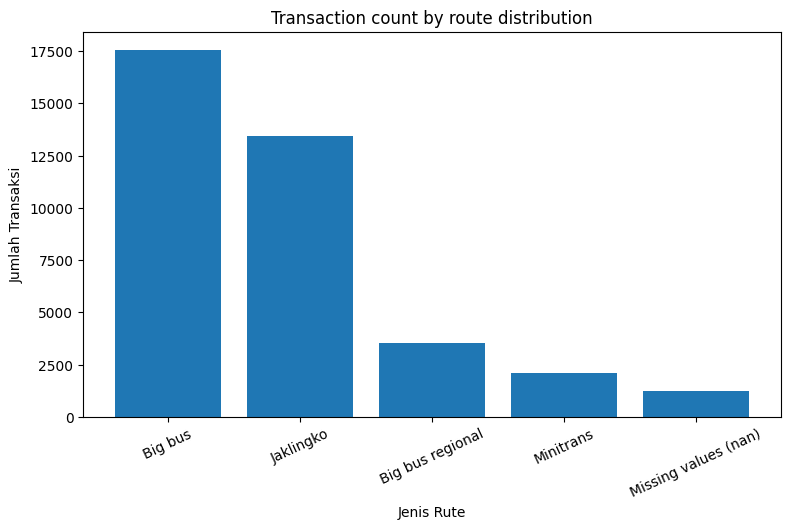

In [60]:
import matplotlib.pyplot as plt


def classify_route(code):
    if code in bus_besar:
        return "Big bus"
    elif code in bus_besar_daerah:
        return "Big bus regional"
    elif code in mikrotrans:
        return "Jaklingko"
    elif code in minitrans:
        return "Minitrans"
    else:
        return "Missing values (nan)"

df["vehicle_group"] = df["corridorID"].apply(classify_route)

counts = df["vehicle_group"].value_counts()

plt.figure(figsize=(9, 5))
plt.bar(counts.index, counts.values)
plt.title("Transaction count by route distribution")
plt.xlabel("Jenis Rute")
plt.ylabel("Jumlah Transaksi")
plt.xticks(rotation=25)
plt.show()

In [61]:
df_bus_besar_all = df2[df2["corridorID"].isin(bus_besar + bus_besar_daerah)].copy()
df_bus_kecil_all = df2[df2["corridorID"].isin(mikrotrans + minitrans)].copy()

This plot shows the generation distribution of users who travel on big bus routes. The users are grouped based on their birth year into Baby Boomer, Gen X, Millennial, and Gen Z.

Since buses have limited passenger capacity and only a limited number of priority seats, it is important to understand how many users may need priority seating. Therefore, this visualization helps us see the demographic distribution first before analyzing potential priority-seat demand in big bus services.

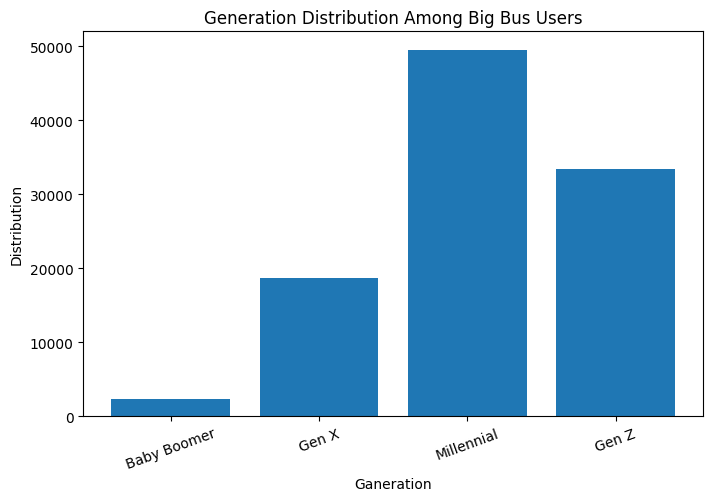

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Pastikan birth year numeric
df_bus_besar_all["payCardBirthDate"] = pd.to_numeric(
    df_bus_besar_all["payCardBirthDate"],
    errors="coerce"
)

# Filter birth year 1946-2012
df_birth = df_bus_besar_all[
    df_bus_besar_all["payCardBirthDate"].between(1946, 2012)
].copy()

def classify_generation(year):
    if 1946 <= year <= 1964:
        return "Baby Boomer"
    elif 1965 <= year <= 1980:
        return "Gen X"
    elif 1981 <= year <= 1996:
        return "Millennial"
    elif 1997 <= year <= 2012:
        return "Gen Z"
    else:
        return "Missing values"

df_birth["generation"] = df_birth["payCardBirthDate"].apply(classify_generation)

gen_order = ["Baby Boomer", "Gen X", "Millennial", "Gen Z"]

gen_counts = (
    df_birth["generation"]
    .value_counts()
    .reindex(gen_order, fill_value=0)
)

plt.figure(figsize=(8, 5))
plt.bar(gen_counts.index, gen_counts.values)
plt.title("Generation Distribution Among Big Bus Users")
plt.xlabel("Ganeration")
plt.ylabel("Distribution")
plt.xticks(rotation=20)
plt.show()

This visualization shows which corridors most often exceed the priority-seat threshold.

The logic is based on passenger movement: when a Baby Boomer or Gen X passenger taps in, the active priority-seat demand on that corridor increases by 1. When they tap out, it decreases by 1. So the warning is not just counting total passengers, but estimating how many priority-seat users are active on the corridor at that moment.

If the active total of Baby Boomer + Gen X passengers goes above 6, the corridor is flagged because it may exceed the available priority seats.

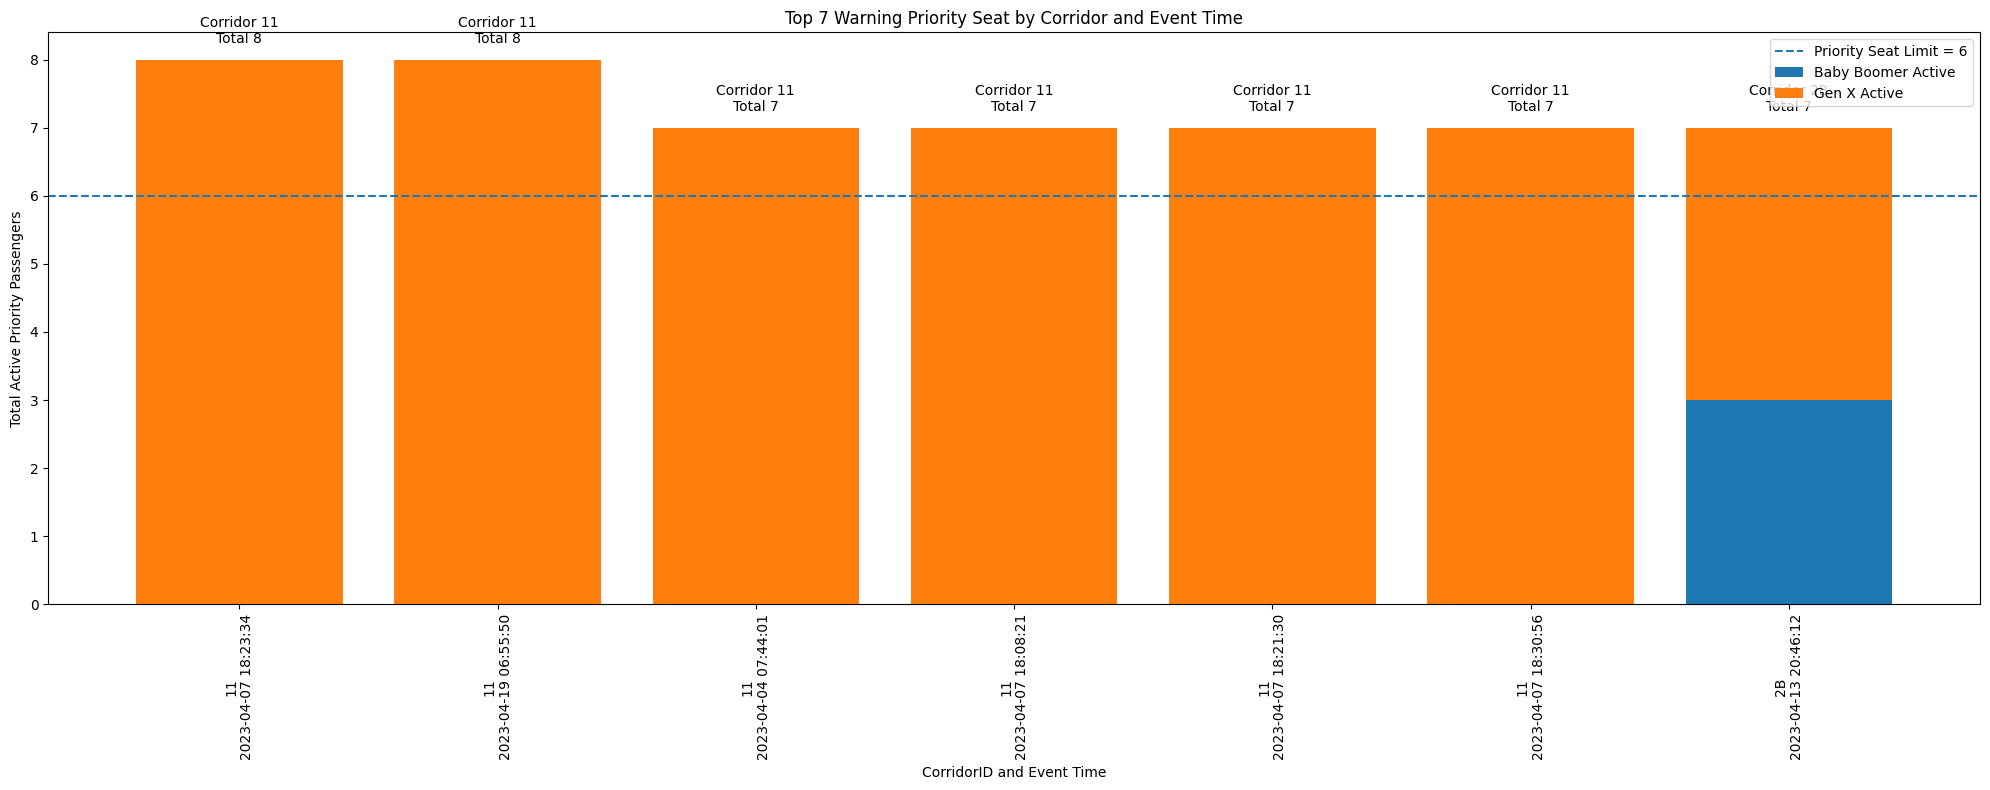

In [63]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# CONFIG
# =========================
TOP_N = 7   # banyak bar yang mau ditampilkan
LIMIT = 6

# pastikan event_time datetime
warning_df["event_time"] = pd.to_datetime(warning_df["event_time"], errors="coerce")

# sort: total_priority terbesar dulu, lalu event_time
plot_df = (
    warning_df
    .sort_values(["total_priority", "event_time"], ascending=[False, True])
    .head(TOP_N)
    .copy()
)

# label x-axis
plot_df["label"] = (
    plot_df["corridorID"].astype(str)
    + "\n"
    + plot_df["event_time"].dt.strftime("%Y-%m-%d %H:%M:%S")
)

plt.figure(figsize=(20, 8))

bar_boomer = plt.bar(
    plot_df["label"],
    plot_df["Baby Boomer Active"],
    label="Baby Boomer Active"
)

bar_genx = plt.bar(
    plot_df["label"],
    plot_df["Gen X Active"],
    bottom=plot_df["Baby Boomer Active"],
    label="Gen X Active"
)

plt.axhline(
    y=LIMIT,
    linestyle="--",
    label=f"Priority Seat Limit = {LIMIT}"
)

# munculin corridorID + total di atas bar
for i, row in plot_df.reset_index(drop=True).iterrows():
    total = row["total_priority"]
    corridor = row["corridorID"]

    plt.text(
        i,
        total + 0.2,
        f"Corridor {corridor}\nTotal {int(total)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title(f"Top {TOP_N} Warning Priority Seat by Corridor and Event Time")
plt.xlabel("CorridorID and Event Time")
plt.ylabel("Total Active Priority Passengers")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

The pie chart then summarizes how often each corridor gets flagged. A larger slice means that corridor appears more frequently in warning conditions, so it may need more attention for priority-seat availability.

corridorID
11     15
2B      1
8D      1
S11     1
Name: count, dtype: int64


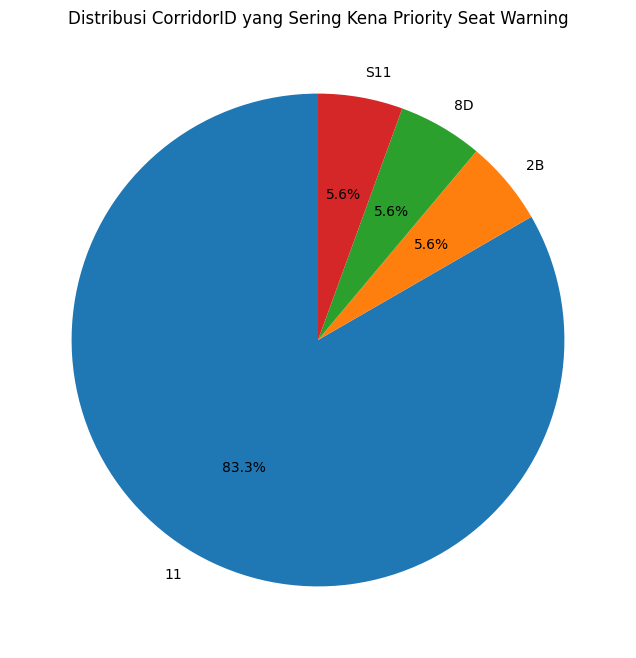

In [64]:
import matplotlib.pyplot as plt

# Hitung frekuensi corridorID kena warning
flag_corridor_counts = (
    warning_df["corridorID"]
    .value_counts()
    .sort_values(ascending=False)
)

print(flag_corridor_counts)

plt.figure(figsize=(8, 8))
plt.pie(
    flag_corridor_counts.values,
    labels=flag_corridor_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribusi CorridorID yang Sering Kena Priority Seat Warning")
plt.show()

This plot shows the estimated active passenger count for each big bus corridor. A passenger is added when they tap in and removed when they tap out, so the value represents the number of passengers estimated to be inside the corridor service at a specific time. Since the assumed bus capacity is 30 passengers, any corridor with an active passenger count above 30 is flagged as potentially over capacity.

Jumlah over-capacity warning: 0


,date,corridorID,event_time,delta,active_passenger,capacity_flag


,date,corridorID,event_time,delta,active_passenger,capacity_flag
13,2023-04-17,11N,2023-04-17 17:25:55,1,19,False
62,2023-04-24,5,2023-04-24 07:09:38,1,18,False
21,2023-04-07,12H,2023-04-07 17:49:44,1,17,False
78,2023-04-28,6Q,2023-04-28 17:46:17,1,17,False
23,2023-04-13,13,2023-04-13 17:52:19,1,17,False
118,2023-04-18,S11,2023-04-18 17:50:53,1,17,False
82,2023-04-24,7,2023-04-24 18:15:04,1,17,False
80,2023-04-14,6U,2023-04-14 17:56:44,1,16,False
36,2023-04-13,1N,2023-04-13 17:54:36,1,15,False
37,2023-04-14,1P,2023-04-14 17:58:53,2,15,False


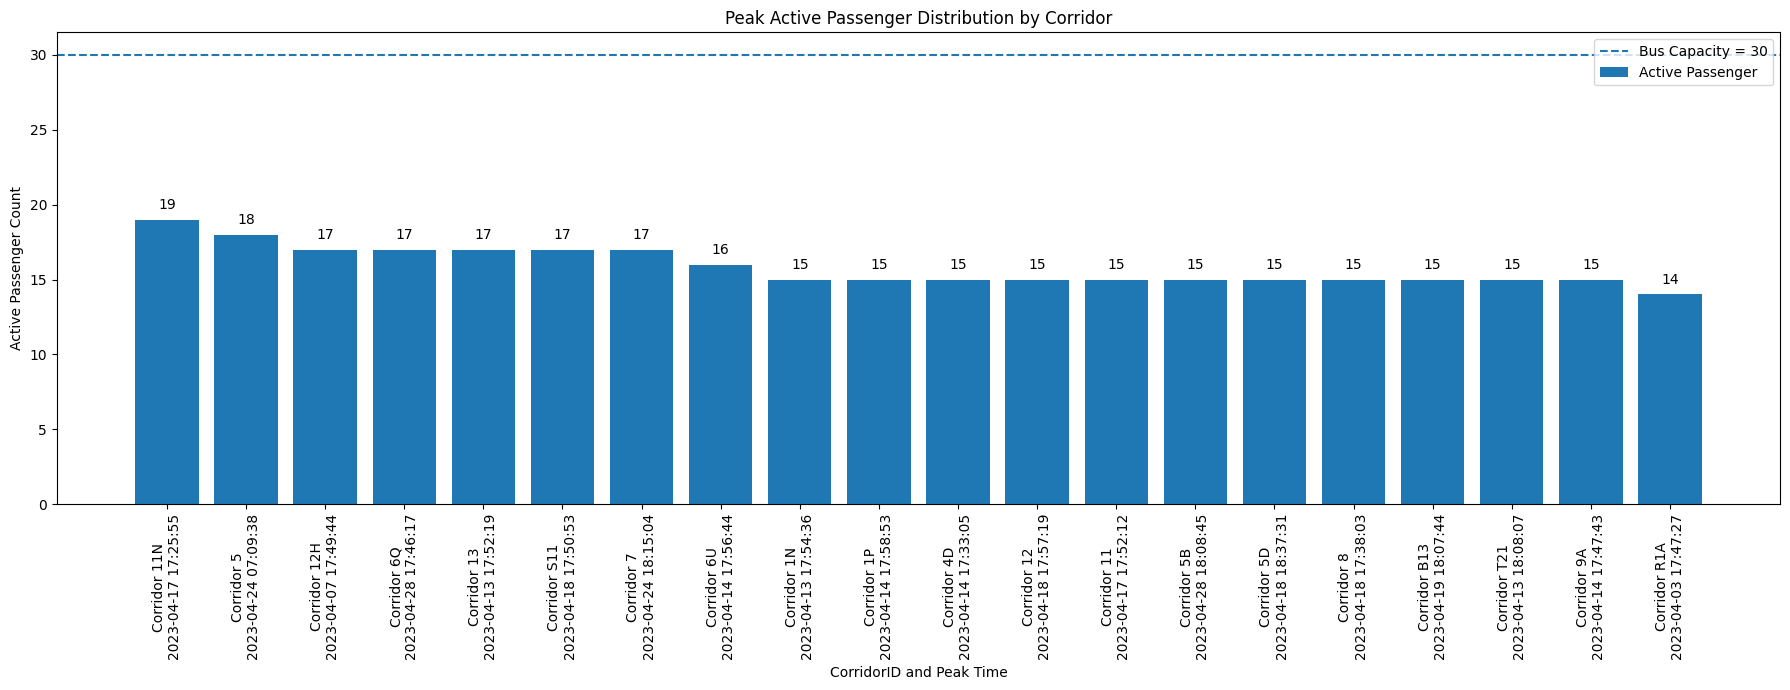

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
BUS_CAPACITY = 30
TOP_N = 20

# =========================
# 1. Copy dari bus besar all
# =========================
df_capacity = df_bus_besar_all.copy()

df_capacity["tapInTime"] = pd.to_datetime(df_capacity["tapInTime"], errors="coerce")
df_capacity["tapOutTime"] = pd.to_datetime(df_capacity["tapOutTime"], errors="coerce")

df_capacity = df_capacity.dropna(
    subset=["tapInTime", "tapOutTime", "corridorID"]
).copy()

# buang data tidak valid
df_capacity = df_capacity[
    df_capacity["tapOutTime"] >= df_capacity["tapInTime"]
].copy()

df_capacity["date"] = df_capacity["tapInTime"].dt.date

# =========================
# 2. Event tap in +1, tap out -1
# =========================
tap_in = df_capacity[["date", "corridorID", "tapInTime"]].copy()
tap_in = tap_in.rename(columns={"tapInTime": "event_time"})
tap_in["delta"] = 1

tap_out = df_capacity[["date", "corridorID", "tapOutTime"]].copy()
tap_out = tap_out.rename(columns={"tapOutTime": "event_time"})
tap_out["delta"] = -1

events = pd.concat([tap_in, tap_out], ignore_index=True)

# =========================
# 3. Gabungkan event yang waktunya sama
# =========================
events_grouped = (
    events
    .groupby(["date", "corridorID", "event_time"])["delta"]
    .sum()
    .reset_index()
)

events_grouped = events_grouped.sort_values(
    ["date", "corridorID", "event_time"]
).reset_index(drop=True)

# =========================
# 4. Hitung active passenger per corridor per hari
# =========================
events_grouped["active_passenger"] = (
    events_grouped
    .groupby(["date", "corridorID"])["delta"]
    .cumsum()
)

events_grouped["active_passenger"] = events_grouped["active_passenger"].clip(lower=0)

events_grouped["capacity_flag"] = events_grouped["active_passenger"] > BUS_CAPACITY

capacity_df = events_grouped.copy()

# =========================
# 5. Warning over capacity
# =========================
capacity_warning_df = (
    capacity_df[capacity_df["capacity_flag"]]
    .sort_values(["active_passenger", "event_time"], ascending=[False, True])
    .reset_index(drop=True)
)

print("Jumlah over-capacity warning:", len(capacity_warning_df))
display(capacity_warning_df.head(20))

# =========================
# 6. Peak passenger per corridor
# =========================
peak_capacity_per_corridor = (
    capacity_df
    .sort_values(["corridorID", "active_passenger"], ascending=[True, False])
    .groupby("corridorID")
    .head(1)
    .reset_index(drop=True)
    .sort_values("active_passenger", ascending=False)
)

display(peak_capacity_per_corridor.head(20))

# =========================
# 7. Plot top corridor yang paling penuh
# =========================
plot_df = peak_capacity_per_corridor.head(TOP_N).copy()

plot_df["label"] = (
    "Corridor " + plot_df["corridorID"].astype(str)
    + "\n" + plot_df["event_time"].dt.strftime("%Y-%m-%d %H:%M:%S")
)

plt.figure(figsize=(18, 7))

plt.bar(
    plot_df["label"],
    plot_df["active_passenger"],
    label="Active Passenger"
)

plt.axhline(
    BUS_CAPACITY,
    linestyle="--",
    label=f"Bus Capacity = {BUS_CAPACITY}"
)

# tampilkan angka di atas bar
for i, row in plot_df.reset_index(drop=True).iterrows():
    plt.text(
        i,
        row["active_passenger"] + 0.5,
        int(row["active_passenger"]),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Peak Active Passenger Distribution by Corridor")
plt.xlabel("CorridorID and Peak Time")
plt.ylabel("Active Passenger Count")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

Unfortunately, no over-capacity flag was triggered in this dataset. This suggests that the dataset does not capture a situation where the estimated active passenger count exceeds the assumed bus capacity of 30 passengers. However, this calculation is based on corridor-level estimation using tap-in and tap-out events, not exact bus-level occupancy, because the dataset does not include a unique bus or vehicle ID.

# **Therefore, we will use object detection to analyze the condition at the individual bus level.**

Since the current dataset only provides tap-in and tap-out records, it can estimate passenger activity by corridor, but it cannot confirm the actual number of passengers inside a specific bus. By using object detection, we can directly observe each bus and estimate whether the bus is crowded, whether the passenger count exceeds capacity, and whether priority seats are potentially occupied beyond the available limit.

Jumlah over-capacity warning bus kecil all: 44


,date,corridorID,event_time,delta,active_passenger,capacity_flag
0,2023-04-14,JAK.11,2023-04-14 17:43:50,1,18,True
1,2023-04-17,JAK.11,2023-04-17 17:57:25,1,18,True
2,2023-04-18,JAK.39,2023-04-18 18:02:11,1,18,True
3,2023-04-05,JAK.39,2023-04-05 17:45:32,1,17,True
4,2023-04-13,JAK.11,2023-04-13 17:10:33,1,17,True
5,2023-04-13,JAK.11,2023-04-13 17:14:28,1,17,True
6,2023-04-13,JAK.11,2023-04-13 17:41:00,1,17,True
7,2023-04-13,JAK.07,2023-04-13 17:59:29,1,17,True
8,2023-04-14,JAK.11,2023-04-14 17:41:06,1,17,True
9,2023-04-14,JAK.11,2023-04-14 17:45:32,-1,17,True


,date,corridorID,event_time,delta,active_passenger,capacity_flag
10,2023-04-14,JAK.11,2023-04-14 17:43:50,1,18,True
45,2023-04-18,JAK.39,2023-04-18 18:02:11,1,18,True
6,2023-04-13,JAK.07,2023-04-13 17:59:29,1,17,True
59,2023-04-17,JAK.51,2023-04-17 18:06:54,1,16,True
50,2023-04-13,JAK.43C,2023-04-13 18:07:39,1,15,False
51,2023-04-07,JAK.44,2023-04-07 17:57:28,1,15,False
1,2023-04-26,JAK.02,2023-04-26 17:35:38,1,15,False
29,2023-04-05,JAK.23,2023-04-05 17:46:58,1,15,False
65,2023-04-11,JAK.59,2023-04-11 18:08:16,1,14,False
36,2023-04-07,JAK.30,2023-04-07 17:50:31,1,14,False


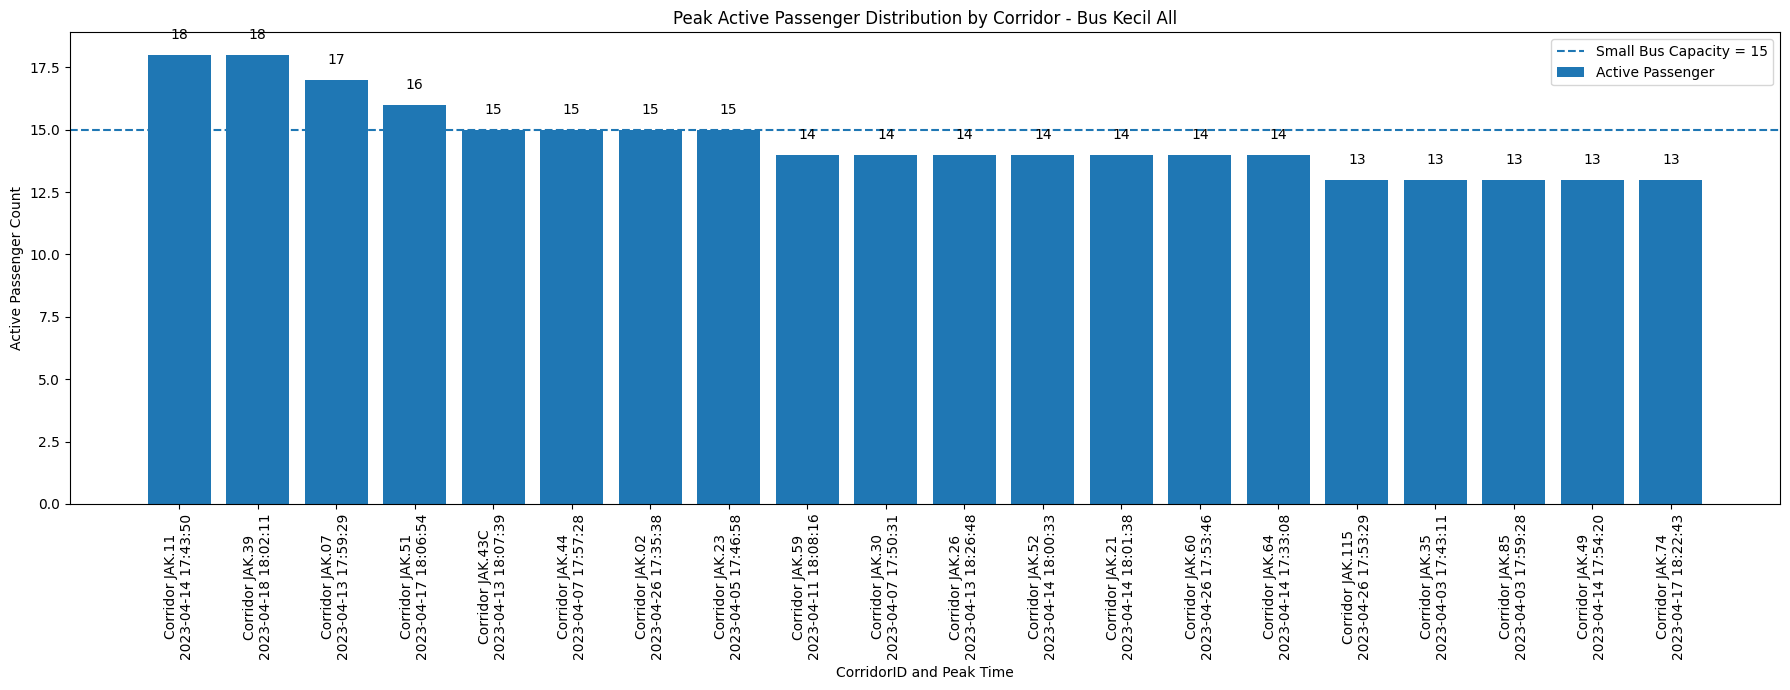

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
BUS_CAPACITY = 15
TOP_N = 20

# =========================
# 1. Copy dari bus kecil all
# =========================
df_capacity = df_bus_kecil_all.copy()

df_capacity["tapInTime"] = pd.to_datetime(df_capacity["tapInTime"], errors="coerce")
df_capacity["tapOutTime"] = pd.to_datetime(df_capacity["tapOutTime"], errors="coerce")

df_capacity = df_capacity.dropna(
    subset=["tapInTime", "tapOutTime", "corridorID"]
).copy()

# buang data tidak valid
df_capacity = df_capacity[
    df_capacity["tapOutTime"] >= df_capacity["tapInTime"]
].copy()

df_capacity["date"] = df_capacity["tapInTime"].dt.date

# =========================
# 2. Event tap in +1, tap out -1
# =========================
tap_in = df_capacity[["date", "corridorID", "tapInTime"]].copy()
tap_in = tap_in.rename(columns={"tapInTime": "event_time"})
tap_in["delta"] = 1

tap_out = df_capacity[["date", "corridorID", "tapOutTime"]].copy()
tap_out = tap_out.rename(columns={"tapOutTime": "event_time"})
tap_out["delta"] = -1

events = pd.concat([tap_in, tap_out], ignore_index=True)

# =========================
# 3. Gabungkan event yang waktunya sama
# =========================
events_grouped = (
    events
    .groupby(["date", "corridorID", "event_time"])["delta"]
    .sum()
    .reset_index()
)

events_grouped = events_grouped.sort_values(
    ["date", "corridorID", "event_time"]
).reset_index(drop=True)

# =========================
# 4. Hitung active passenger per corridor per hari
# =========================
events_grouped["active_passenger"] = (
    events_grouped
    .groupby(["date", "corridorID"])["delta"]
    .cumsum()
)

events_grouped["active_passenger"] = events_grouped["active_passenger"].clip(lower=0)

events_grouped["capacity_flag"] = events_grouped["active_passenger"] > BUS_CAPACITY

capacity_df_bus_kecil_all = events_grouped.copy()

# =========================
# 5. Warning over capacity
# =========================
capacity_warning_df_bus_kecil_all = (
    capacity_df_bus_kecil_all[capacity_df_bus_kecil_all["capacity_flag"]]
    .sort_values(["active_passenger", "event_time"], ascending=[False, True])
    .reset_index(drop=True)
)

print("Jumlah over-capacity warning bus kecil all:", len(capacity_warning_df_bus_kecil_all))
display(capacity_warning_df_bus_kecil_all.head(20))

# =========================
# 6. Peak passenger per corridor
# =========================
peak_capacity_per_corridor_bus_kecil_all = (
    capacity_df_bus_kecil_all
    .sort_values(["corridorID", "active_passenger"], ascending=[True, False])
    .groupby("corridorID")
    .head(1)
    .reset_index(drop=True)
    .sort_values("active_passenger", ascending=False)
)

display(peak_capacity_per_corridor_bus_kecil_all.head(20))

# =========================
# 7. Plot top corridor yang paling penuh
# =========================
plot_df = peak_capacity_per_corridor_bus_kecil_all.head(TOP_N).copy()

plot_df["label"] = (
    "Corridor " + plot_df["corridorID"].astype(str)
    + "\n" + plot_df["event_time"].dt.strftime("%Y-%m-%d %H:%M:%S")
)

plt.figure(figsize=(18, 7))

plt.bar(
    plot_df["label"],
    plot_df["active_passenger"],
    label="Active Passenger"
)

plt.axhline(
    BUS_CAPACITY,
    linestyle="--",
    label=f"Small Bus Capacity = {BUS_CAPACITY}"
)

for i, row in plot_df.reset_index(drop=True).iterrows():
    plt.text(
        i,
        row["active_passenger"] + 0.5,
        int(row["active_passenger"]),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Peak Active Passenger Distribution by Corridor - Bus Kecil All")
plt.xlabel("CorridorID and Peak Time")
plt.ylabel("Active Passenger Count")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

In [67]:
df_bus_besar_all.to_csv("bus_besar_all.csv", index=False)
df_bus_kecil_all.to_csv("bus_kecil_all.csv", index=False)

In [68]:
from google.colab import files

files.download("bus_besar_all.csv")
files.download("bus_kecil_all.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>